# C&C Distribution — worked solution

**Instructor copy. Do not share with the class.**

The brief is `cc-distribution-profitability.pdf`. The data is the nine `cc_*` files.
Every figure in the teaching note comes from this notebook, so if the dataset is
regenerated with a different seed, re-run this and update the note.

The order below is the order the work has to happen in. Steps 1 and 2 are the case:
everything after them is ordinary analysis that any tool does correctly once the
columns mean what you think they mean.


## 0. Load

Four order books that agree on nothing: column names, date formats, decimal
separators, currency, and which side of VAT they sit on.


In [1]:
import pandas as pd, numpy as np, datetime as dt

B  = pd.read_csv('cc_baltics_sales.csv')
PL = pd.read_csv('cc_poland_sales.csv')
CZ = pd.read_csv('cc_czechia_sales.csv')
DE = pd.read_csv('cc_germany_sales.csv')
RET  = pd.read_csv('cc_returns.csv', dtype={'order_id': str})
PROD = pd.read_csv('cc_products.csv')
PROMO = pd.read_csv('cc_promotions.csv')
CAMP = pd.read_csv('cc_campaigns.csv')
FX = pd.read_csv('cc_fx_rates.csv').set_index('currency')['units_per_eur'].to_dict()
print({k: len(v) for k, v in {'BALT': B, 'PL': PL, 'CZ': CZ, 'DE': DE, 'RET': RET}.items()})

import matplotlib, matplotlib.pyplot as plt
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})
def finish(ax, title, sub=None):
    ax.set_title(title, loc="left")
    if sub: ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=9, color="#6b6485")
    plt.tight_layout(); plt.show()


{'BALT': 9312, 'PL': 6889, 'CZ': 2683, 'DE': 3943, 'RET': 3917}


## 1. The wrong answer, so the class can see it

This is what a model returns when it is handed the four files and asked which
market is biggest. Nothing here is a calculation error.


In [2]:
naive = {
    'Czechia': CZ['castka'].sum(),
    'Poland':  PL['wartosc_netto'].str.replace(',', '.').astype(float).sum(),
    'Baltics': B['net_amount'].sum(),
    'Germany': DE['bruttobetrag'].sum(),
}
pd.Series(naive).sort_values(ascending=False).map('{:,.0f}'.format)


Czechia    55,834,828
Poland     31,444,617
Baltics     7,827,255
Germany     3,919,732
dtype: str

Czechia, by a distance. It is the smallest market in the group.


## 2. Make the four books comparable

Three corrections, and the case turns on all three being found:

1. **Currency.** Poland is zloty, Czechia is koruna. No column says so; the file
   name and `cc_fx_rates.csv` do.
2. **VAT.** Germany is gross at 19 per cent. The other three are net.
3. **Units.** Poland books pack multiples separately, so units are
   `ilosc * krotnosc_opakowania`. The discount is whole per cent in Poland and a
   fraction everywhere else, which matters if you recompute rather than use the
   line value.


In [3]:
def norm(df, country, oid, date, sku, qty, amount, promo, fx=1.0, vat=1.0, mult=None, datefmt=None):
    out = pd.DataFrame({
        'order_id': df[oid].astype(str),
        'date': pd.to_datetime(df[date], format=datefmt),
        'sku': df[sku],
        'units': df[qty] * (df[mult] if mult else 1),
        'promo': df[promo].fillna(''),
        'segment': df['segment'] if 'segment' in df else df.get('segment'),
    })
    # Poland writes decimals with a comma, and reads back as text. Coerce
    # rather than test the dtype: what pandas calls a string column has
    # changed twice between versions and will change again.
    amt = pd.to_numeric(df[amount].astype(str).str.replace(',', '.'), errors='raise')
    out['net_eur'] = amt / fx / vat          # to euro, and net of VAT
    # 'country' can be a literal ('PL') or the name of a column that already
    # holds one ('country', in the Baltic extract, which covers three markets).
    # Testing isinstance(str) could not tell them apart, so every Baltic row
    # was labelled with the literal string 'country' and Latvia, Lithuania and
    # Estonia were collapsed into one market that does not exist. Ask the frame.
    out['country'] = df[country] if (isinstance(country, str) and country in df.columns) else country
    return out

b  = norm(B,  'country',  'order_id', 'order_date', 'sku', 'quantity', 'net_amount', 'promo_code')
pl = norm(PL, 'PL', 'nr_zamowienia', 'data_zamowienia', 'indeks', 'ilosc', 'wartosc_netto',
          'kod_promocyjny', fx=FX['PLN'], mult='krotnosc_opakowania', datefmt='%d.%m.%Y')
cz = norm(CZ, 'CZ', 'cislo_objednavky', 'datum', 'kod_zbozi', 'mnozstvi', 'castka',
          'promo', fx=FX['CZK'], datefmt='%d/%m/%Y')
de = norm(DE, 'DE', 'bestellnummer', 'bestelldatum', 'artikelnummer', 'menge', 'bruttobetrag',
          'aktionscode', vat=1.19)
S = pd.concat([b, pl, cz, de], ignore_index=True)
S = S.merge(PROD, on='sku', how='left')
S['cost_eur'] = S['unit_cost_eur'] * S['units']
S['gp_eur'] = S['net_eur'] - S['cost_eur']
print(f"{len(S):,} lines · revenue EUR {S['net_eur'].sum():,.0f} · gross profit EUR {S['gp_eur'].sum():,.0f}")


22,827 lines · revenue EUR 20,482,188 · gross profit EUR 2,816,737


## 3. Returns

One row per item, not per order, and the 2022 migration duplicated part of the
file. Drop the duplicate ids first; joining without doing so multiplies revenue
on every order it touches.


In [4]:
print('rows', len(RET), 'distinct return_id', RET['return_id'].nunique())
R = RET.drop_duplicates('return_id')
ru = R.groupby(['order_id', 'sku'])['units_returned'].sum().rename('ret_units')
S = S.merge(ru, left_on=['order_id', 'sku'], right_index=True, how='left')
S['ret_units'] = S['ret_units'].fillna(0)
S['kept'] = (S['units'] - S['ret_units']).clip(lower=0) / S['units'].clip(lower=1)
S['net_after_ret'] = S['net_eur'] * S['kept']
S['gp_after_ret'] = S['gp_eur'] * S['kept']
print(f"return rate on units: {S['ret_units'].sum() / S['units'].sum():.2%}")


rows 3917 distinct return_id 3810
return rate on units: 5.99%


## 4. Question one — where the profit comes from


In [5]:
by_mkt = S.groupby('country').agg(revenue=('net_after_ret', 'sum'),
                                  gross_profit=('gp_after_ret', 'sum')).sort_values('gross_profit', ascending=False)
by_mkt['margin'] = by_mkt['gross_profit'] / by_mkt['revenue']
by_mkt.style.format({'revenue': '{:,.0f}', 'gross_profit': '{:,.0f}', 'margin': '{:.1%}'})


,revenue,gross_profit,margin
country,,,
PL,"6,565,046","913,089",13.9%
LV,"3,029,848","435,284",14.4%
LT,"2,668,443","396,072",14.8%
DE,"3,050,401","387,586",12.7%
CZ,"2,246,874","288,178",12.8%
EE,"1,606,988","232,365",14.5%


## 5. Question two — the assortment

The finding: accessories and services are about a seventh of revenue and more
than half the gross profit. iPhone and Mac are most of the revenue and a quarter
of the profit. The board conclusion is not to stop selling Macs, it is that the
company is an attach-rate business and is measuring itself as a hardware one.


In [6]:
fam = S.groupby('family').agg(revenue=('net_eur', 'sum'), gross_profit=('gp_eur', 'sum'),
                              units=('units', 'sum')).sort_values('gross_profit', ascending=False)
fam['margin'] = fam['gross_profit'] / fam['revenue']
fam['share_of_revenue'] = fam['revenue'] / fam['revenue'].sum()
fam['share_of_profit'] = fam['gross_profit'] / fam['gross_profit'].sum()
fam.style.format({'revenue': '{:,.0f}', 'gross_profit': '{:,.0f}', 'units': '{:,.0f}',
                  'margin': '{:.1%}', 'share_of_revenue': '{:.1%}', 'share_of_profit': '{:.1%}'})


,revenue,gross_profit,units,margin,share_of_revenue,share_of_profit
family,,,,,,
Accessory,"1,916,770","993,224","23,364",51.8%,9.4%,35.3%
Service,"976,274","590,865","6,169",60.5%,4.8%,21.0%
iPhone,"5,559,857","375,047","8,174",6.7%,27.1%,13.3%
Mac,"7,353,171","328,476","6,164",4.5%,35.9%,11.7%
iPad,"2,377,385","282,144","4,891",11.9%,11.6%,10.0%
Audio,"1,496,906","210,946","7,652",14.1%,7.3%,7.5%
Watch,"801,824","36,034","2,378",4.5%,3.9%,1.3%


### Legacy stock

Negative margin, on purpose. Whether that is a failure or a working-capital
decision cannot be settled from these files, and the best student answers say so
and name what they would need: holding cost, write-down policy, stock age.


In [7]:
leg = S.groupby('is_legacy').agg(revenue=('net_eur', 'sum'), gross_profit=('gp_eur', 'sum'))
leg['margin'] = leg['gross_profit'] / leg['revenue']
below = S[S['gp_eur'] < 0]
print(leg.to_string())
print(f"\nlines below cost: {len(below):,} ({len(below)/len(S):.1%}), gross profit EUR {below['gp_eur'].sum():,.0f}")


                revenue  gross_profit    margin
is_legacy                                      
0          1.383901e+07  3.268609e+06  0.236188
1          6.643174e+06 -4.518717e+05 -0.068020

lines below cost: 3,248 (14.2%), gross profit EUR -644,258


## 6. Question three — what the discounts cost

Three of the thirteen codes are not marketing: CLEARANCE is a stock decision,
STAFF30 is a staff benefit, PARTNER15 is a reseller agreement. A campaign report
that counts them overstates what marketing spends.


In [8]:
pr = S.assign(promo=S['promo'].replace('', '(none)')).groupby('promo').agg(
        revenue=('net_eur', 'sum'), gross_profit=('gp_eur', 'sum'), lines=('sku', 'size'))
pr['margin'] = pr['gross_profit'] / pr['revenue']
pr.sort_values('revenue', ascending=False).style.format(
    {'revenue': '{:,.0f}', 'gross_profit': '{:,.0f}', 'margin': '{:.1%}'})


,revenue,gross_profit,lines,margin
promo,,,,
(none),"15,276,254","2,736,368",16376,17.9%
WELCOME10,"2,039,717","331,599",2240,16.3%
CLEARANCE,"1,839,093","-352,370",2816,-19.2%
PARTNER15,"496,527","31,749",339,6.4%
EDU5,"386,579","56,654",613,14.7%
BACK2SCHOOL22,"93,977","1,663",44,1.8%
BACK2SCHOOL24,"80,668",11,62,0.0%
BACK2SCHOOL23,"71,482","-1,466",54,-2.1%
BLACKFRI24,"66,869","2,206",73,3.3%


## 7. Question four, advanced — do the campaigns pay?

Gross profit inside each window against the same number of trading days
immediately before it, then the media spend taken off.

The baseline is deliberately generous: June and July are the seasonal trough and
the September launch falls inside the window, so the comparison flatters the
campaign. Every year still loses, and in 2023 and 2024 in-window gross profit is
*lower* than the period before, which is what discounting into demand that was
coming anyway looks like.

State the limit out loud: this is a before-and-after comparison, not an
experiment, and it cannot separate the campaign from the season. The fix costs
nothing: run the discount in three markets in 2025 and not in the other three.


In [9]:
mac = S[S['family'] == 'Mac']
rows = []
for _, c in CAMP[CAMP['target_family'] == 'Mac'].iterrows():
    s, e = pd.Timestamp(c['start_date']), pd.Timestamp(c['end_date'])
    days = (e - s).days + 1
    mk = c['markets'].split('|')
    inw = mac[(mac['date'].between(s, e)) & (mac['country'].isin(mk))]['gp_eur'].sum()
    base = mac[(mac['date'].between(s - pd.Timedelta(days=days*2), s - pd.Timedelta(days=1)))
               & (mac['country'].isin(mk))]['gp_eur'].sum() / 2
    rows.append({'campaign': c['campaign_id'], 'in_window_gp': inw, 'baseline_gp': base,
                 'uplift': inw - base, 'spend': c['spend_eur'], 'net': inw - base - c['spend_eur']})
pd.DataFrame(rows).set_index('campaign').style.format('{:,.0f}')


,in_window_gp,baseline_gp,uplift,spend,net
campaign,,,,,
CMP-2021-B2S,"4,045",950,"3,095","48,000","-44,905"
CMP-2022-B2S,"-1,080","-3,313","2,233","96,000","-93,767"
CMP-2023-B2S,"-8,704","11,345","-20,050","141,000","-161,050"
CMP-2024-B2S,"19,545","23,761","-4,216","210,000","-214,216"


---
## Visual summary

The same answers, as pictures. Project these; do not hand them out. A chart of
corrected against naive revenue is the whole case in one image, and a student
who sees it before they have done the reconciliation has been robbed of the
only part that teaches anything.

These cells are stripped from the student edition automatically. The heading
above is what does it.

findfont: Failed to find font weight 600, now using 700.


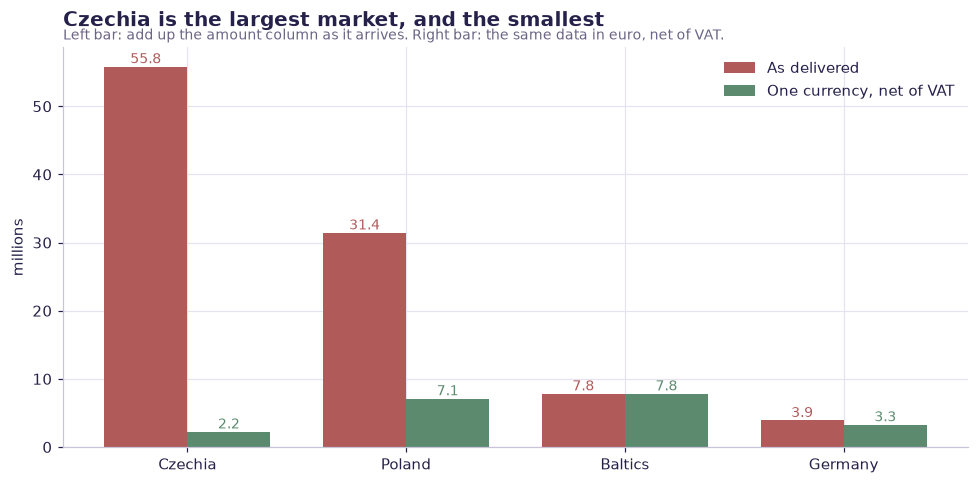

In [10]:
# 1 — the wrong answer and the right one, side by side
import numpy as np
naive_m = {"Czechia": CZ["castka"].sum()/1e6,
           "Poland":  pd.to_numeric(PL["wartosc_netto"].astype(str).str.replace(",", "."), errors="coerce").sum()/1e6,
           "Baltics": B["net_amount"].sum()/1e6,
           "Germany": DE["bruttobetrag"].sum()/1e6}
grp = {"Baltics": ["LV","LT","EE"], "Poland": ["PL"], "Czechia": ["CZ"], "Germany": ["DE"]}
true_m = {k: S[S["country"].isin(v)]["net_eur"].sum()/1e6 for k, v in grp.items()}
order = sorted(naive_m, key=lambda k: -naive_m[k])
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, [naive_m[k] for k in order], w, label="As delivered", color=DANGER)
ax.bar(x + w/2, [true_m[k] for k in order], w, label="One currency, net of VAT", color=CORE)
for i, k in enumerate(order):
    ax.text(i - w/2, naive_m[k], f"{naive_m[k]:,.1f}", ha="center", va="bottom", fontsize=9, color=DANGER)
    ax.text(i + w/2, true_m[k], f"{true_m[k]:,.1f}", ha="center", va="bottom", fontsize=9, color=CORE)
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel("millions"); ax.legend(frameon=False)
finish(ax, "Czechia is the largest market, and the smallest",
       "Left bar: add up the amount column as it arrives. Right bar: the same data in euro, net of VAT.")

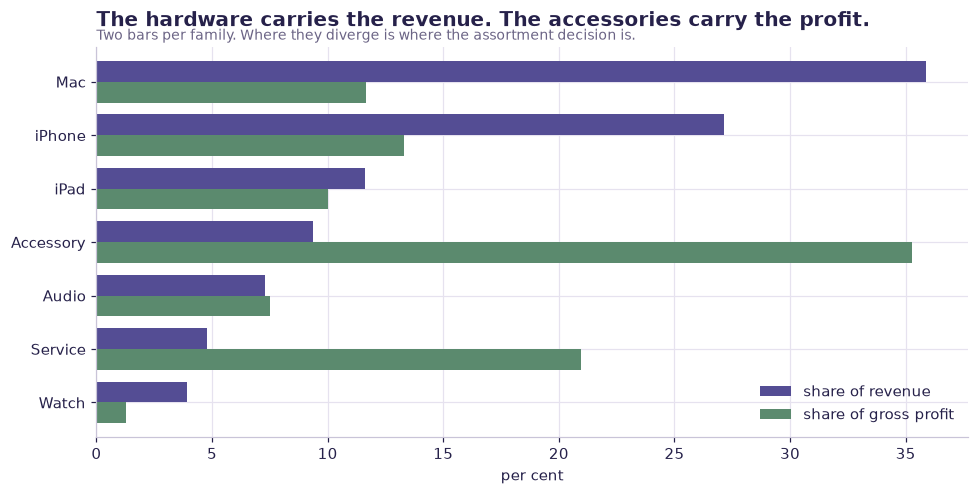

In [11]:
# 2 — where the profit actually is, against where the revenue is
fam = (S.groupby("family").agg(revenue=("net_eur","sum"), gp=("gp_eur","sum"))
         .sort_values("revenue", ascending=False))
sh = pd.DataFrame({"share of revenue": fam["revenue"]/fam["revenue"].sum()*100,
                   "share of gross profit": fam["gp"]/fam["gp"].sum()*100})
fig, ax = plt.subplots(figsize=(9, 4.6))
sh.plot.barh(ax=ax, color=[ACCENT, CORE], width=.78)
ax.invert_yaxis(); ax.set_xlabel("per cent"); ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
finish(ax, "The hardware carries the revenue. The accessories carry the profit.",
       "Two bars per family. Where they diverge is where the assortment decision is.")

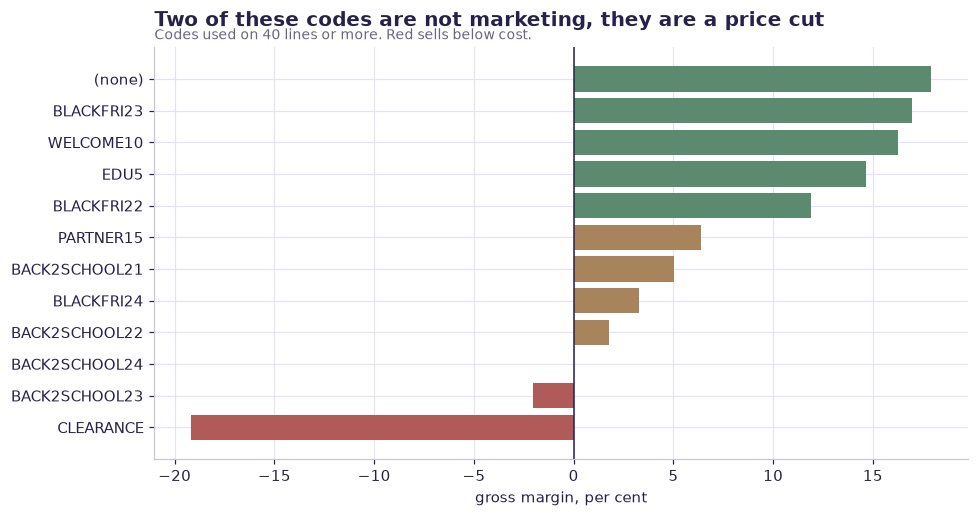

In [12]:
# 3 — what each discount code actually costs
pr = (S.assign(promo=S["promo"].replace("", "(none)"))
        .groupby("promo").agg(lines=("net_eur","size"), revenue=("net_eur","sum"),
                              gp=("gp_eur","sum")))
pr["margin_pc"] = pr["gp"]/pr["revenue"]*100
pr = pr[pr["lines"] >= 40].sort_values("margin_pc")
fig, ax = plt.subplots(figsize=(9, 4.8))
cols = [DANGER if m < 0 else (BUILDER if m < 8 else CORE) for m in pr["margin_pc"]]
ax.barh(pr.index, pr["margin_pc"], color=cols)
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel("gross margin, per cent")
finish(ax, "Two of these codes are not marketing, they are a price cut",
       "Codes used on 40 lines or more. Red sells below cost.")

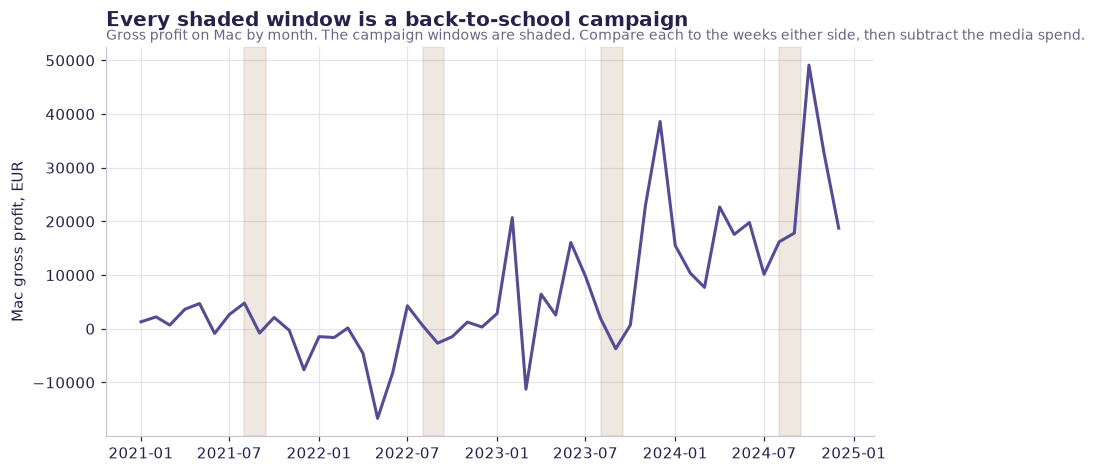

In [13]:
# 4 — do the back-to-school campaigns pay?
mac = S[S["family"] == "Mac"].copy()
mac["month"] = mac["date"].dt.to_period("M").dt.to_timestamp()
m = mac.groupby("month").agg(gp=("gp_eur","sum"))
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.plot(m.index, m["gp"], color=ACCENT, lw=2)
for _, c in CAMP.iterrows():
    if "B2S" not in str(c["campaign_id"]): continue
    ax.axvspan(pd.to_datetime(c["start_date"]), pd.to_datetime(c["end_date"]),
               color=BUILDER, alpha=.18)
ax.set_ylabel("Mac gross profit, EUR")
finish(ax, "Every shaded window is a back-to-school campaign",
       "Gross profit on Mac by month. The campaign windows are shaded. Compare each to the weeks either side, then subtract the media spend.")

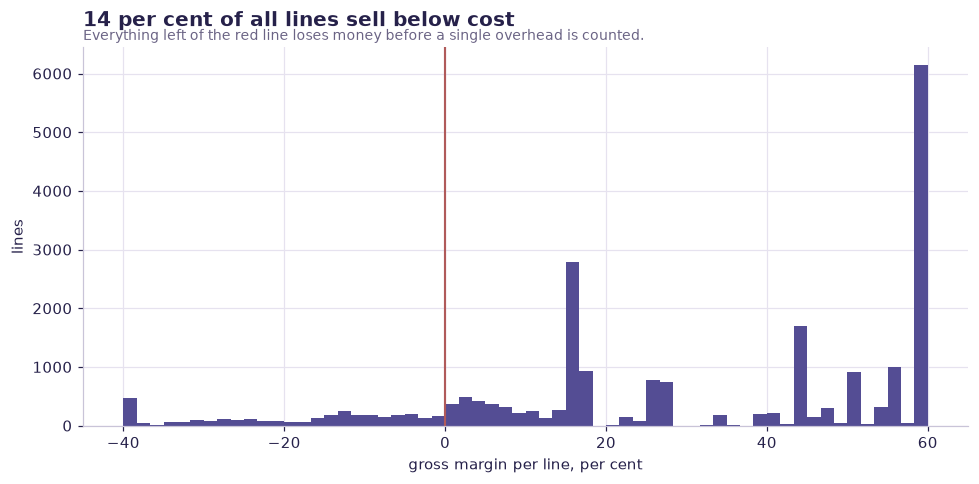

In [14]:
# 5 — the shape of the discounting, which is where the margin went
d = S[S["net_eur"] > 0].copy()
d["margin_pc"] = d["gp_eur"]/d["net_eur"]*100
fig, ax = plt.subplots()
ax.hist(d["margin_pc"].clip(-40, 60), bins=60, color=ACCENT)
ax.axvline(0, color=DANGER, lw=1.4)
below = (d["margin_pc"] < 0).mean()*100
ax.set_xlabel("gross margin per line, per cent"); ax.set_ylabel("lines")
finish(ax, f"{below:.0f} per cent of all lines sell below cost",
       "Everything left of the red line loses money before a single overhead is counted.")

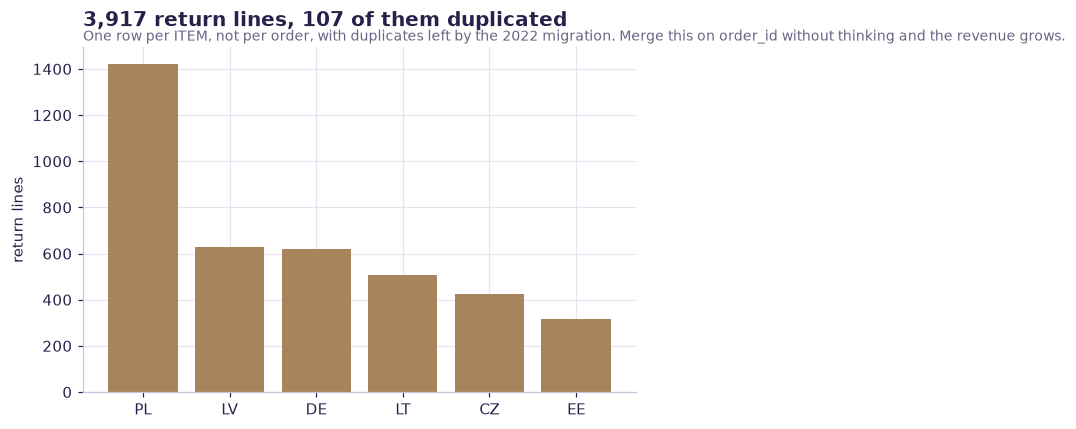

In [15]:
# 6 — returns, and the duplicate rows a plain merge would multiply
dupes = len(RET) - RET["return_id"].nunique()
by_c = RET.groupby("country").size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8.4, 4))
ax.bar(by_c.index, by_c.values, color=BUILDER)
ax.set_ylabel("return lines")
finish(ax, f"{len(RET):,} return lines, {dupes} of them duplicated",
       "One row per ITEM, not per order, with duplicates left by the 2022 migration. Merge this on order_id without thinking and the revenue grows.")

## 8. The one-page answer

1. The Baltics are the largest market and Czechia the smallest. The founders
   believe the reverse because nobody converted the currency.
2. Accessories and services carry the company. Hardware buys the footfall.
3. The largest discount in the business is a stock clearance booked as a promotion.
4. Back to school has lost money every year it has run, and the loss grows with
   the budget. Do not renew it blind; run it as a holdout in 2025 and find out.
